In [ ]:
# Verify GPU + mount Drive (optional but useful for saving checkpoints later)
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

from google.colab import drive
drive.mount('/content/drive')

GPU: Tesla T4
Mounted at /content/drive


In [ ]:
%%capture
!pip install librosa soundfile datasets torchaudio matplotlib \
            seaborn pandas numpy kaggle

In [ ]:
!wget -q https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2
!tar -xjf LJSpeech-1.1.tar.bz2
# structure: LJSpeech-1.1/wavs/*.wav  +  metadata.csv

In [ ]:
import pandas as pd

# LJSpeech metadata
df = pd.read_csv('LJSpeech-1.1/metadata.csv', sep='|',
                 header=None,
                 names=['id', 'transcript', 'normalized'])
df['wav_path'] = 'LJSpeech-1.1/wavs/' + df['id'] + '.wav'
df['text_len'] = df['normalized'].str.len()
print(df.shape)
df.head(3)

(13100, 5)


,id,transcript,normalized,wav_path,text_len
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ...",LJSpeech-1.1/wavs/LJ001-0001.wav,151.0
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.,LJSpeech-1.1/wavs/LJ001-0002.wav,30.0
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...,LJSpeech-1.1/wavs/LJ001-0003.wav,155.0


In [ ]:
import librosa, numpy as np
from tqdm import tqdm

def get_stats(path):
    y, sr = librosa.load(path, sr=None)
    return {'sr': sr,
            'duration': len(y) / sr,
            'rms': float(np.sqrt(np.mean(y**2))),
            'samples': len(y)}

sample = df.sample(500, random_state=42)
stats = [get_stats(p) for p in tqdm(sample['wav_path'])]
stats_df = pd.DataFrame(stats)
stats_df.describe()

100%|██████████| 500/500 [00:27<00:00, 18.48it/s] 


,sr,duration,rms,samples
count,500.0,500.000000,500.000000,500.000000
mean,22050.0,6.539799,0.066265,144202.568000
std,0.0,2.126349,0.009895,46885.993598
min,22050.0,1.110068,0.042680,24477.000000
25%,22050.0,5.074875,0.059205,111901.000000
50%,22050.0,6.764127,0.065483,149149.000000
75%,22050.0,8.241497,0.072341,181725.000000
max,22050.0,10.084580,0.107587,222365.000000


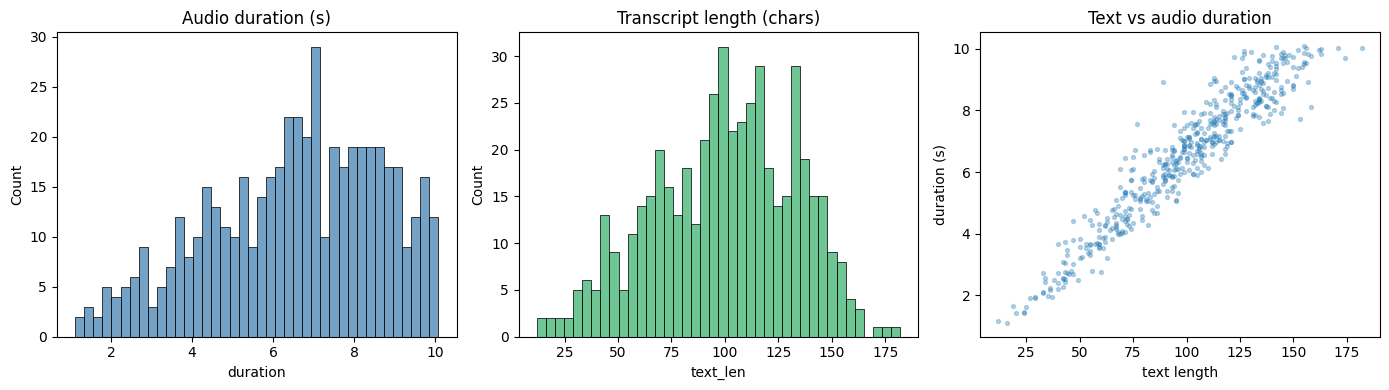

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(stats_df['duration'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Audio duration (s)')

sns.histplot(sample['text_len'], bins=40, ax=axes[1], color='mediumseagreen')
axes[1].set_title('Transcript length (chars)')

axes[2].scatter(sample['text_len'].values,
                stats_df['duration'].values, alpha=0.3, s=8)
axes[2].set_xlabel('text length'); axes[2].set_ylabel('duration (s)')
axes[2].set_title('Text vs audio duration')

plt.tight_layout(); plt.show()

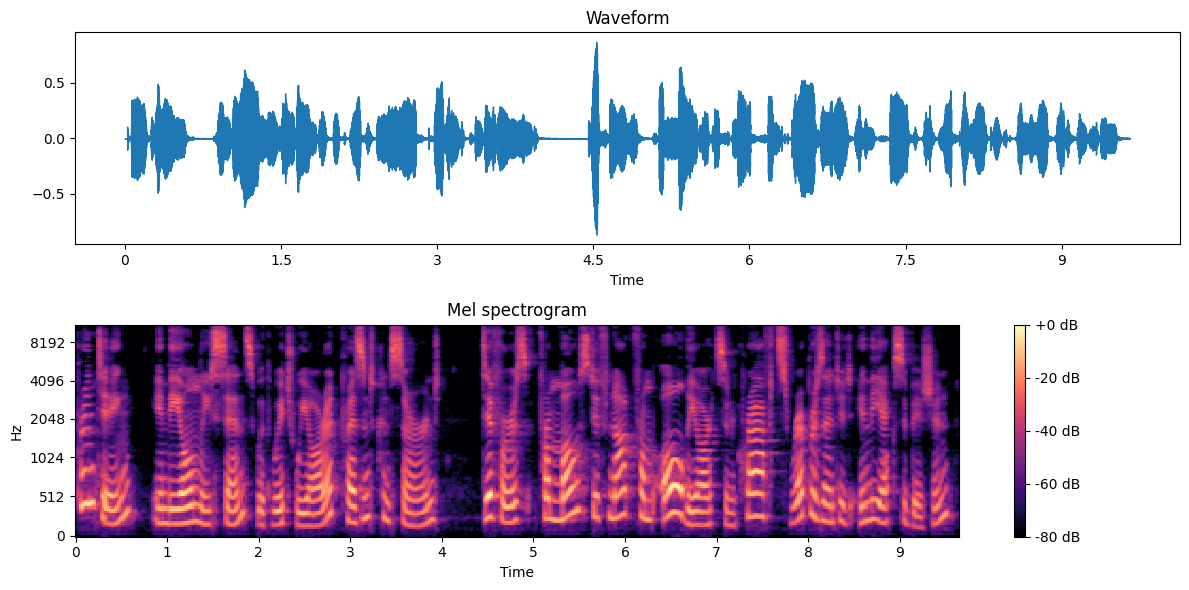

In [ ]:
import librosa.display

path = df['wav_path'].iloc[0]
y, sr = librosa.load(path, sr=None)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title('Waveform')

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, sr=sr, x_axis='time',
                         y_axis='mel', ax=axes[1])
axes[1].set_title('Mel spectrogram')
fig.colorbar(axes[1].collections[0], ax=axes[1], format='%+2.0f dB')

plt.tight_layout(); plt.show()

In [ ]:
merged = sample.reset_index(drop=True)
merged['duration'] = stats_df['duration']
merged['rms']      = stats_df['rms']

before = len(merged)
clean = merged[
    (merged['duration'] >= 1.0) &   # drop very short
    (merged['duration'] <= 12.0) &  # drop very long
    (merged['rms']      >= 0.005)   # drop near-silent
]
print(f"Kept {len(clean)}/{before} clips ({len(clean)/before:.1%})")

Kept 500/500 clips (100.0%)


In [ ]:
import pandas as pd

# reload full metadata
df_full = pd.read_csv('LJSpeech-1.1/metadata.csv', sep='|', header=None,
                      names=['id','transcript','normalized'])
df_full['wav_path'] = 'LJSpeech-1.1/wavs/' + df_full['id'] + '.wav'
df_full['text_len'] = df_full['normalized'].str.len()

# apply filters on full set (no audio stats needed — LJSpeech is already clean)
clean_full = df_full[
    (df_full['text_len'] >= 5) &    # drop near-empty transcripts
    (df_full['text_len'] <= 190)    # drop outlier-long ones
]

clean_full[['id','wav_path','normalized','text_len']]\
    .to_csv('manifest_clean.csv', index=False)

print(f"{len(clean_full)}/{len(df_full)} clips kept ({len(clean_full)/len(df_full):.1%})")

13084/13100 clips kept (99.9%)


Splitting Data


In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/manifest_clean.csv')

# first split off test (10%)
train_val, test = train_test_split(df, test_size=0.10, random_state=42)

# then split train/val from the remaining 90%
train, val = train_test_split(train_val, test_size=0.111, random_state=42)
# 0.111 of 90% ≈ 10% of total → gives you 80/10/10

print(f"train : {len(train):,}")
print(f"val   : {len(val):,}")
print(f"test  : {len(test):,}")

train.to_csv('/content/train.csv', index=False)
val.to_csv('/content/val.csv',   index=False)
test.to_csv('/content/test.csv',  index=False)

train : 10,467
val   : 1,308
test  : 1,309


Audio Encoder

In [ ]:
%%capture
!pip install transformers datasets accelerate \
            torchaudio soundfile librosa \
            tensorboard evaluate jiwer

In [ ]:
MODEL_ID      = "openai/whisper-small"
TRAIN_CSV     = "/content/train.csv"
VAL_CSV       = "/content/val.csv"
WAV_ROOT      = ""              # paths in csv are already relative to /content
OUTPUT_DIR    = "/content/whisper-finetuned"
SAMPLE_RATE   = 16000            # whisper expects 16kHz (not 22050)
MAX_DURATION  = 30               # whisper hard limit (seconds)
BATCH_SIZE    = 8                # safe for T4 16GB with grad checkpointing
GRAD_ACCUM    = 4                # effective batch = 32
LR            = 1e-5
WARMUP_STEPS  = 500
MAX_STEPS     = 4000
SAVE_STEPS    = 500
EVAL_STEPS    = 500
FP16          = True

In [ ]:
import torch, torchaudio, pandas as pd
from torch.utils.data import Dataset
from transformers import WhisperProcessor

processor = WhisperProcessor.from_pretrained(MODEL_ID)
resampler = torchaudio.transforms.Resample(22050, SAMPLE_RATE)

class LJSpeechDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        wav, sr = torchaudio.load(f"/content/{row['wav_path']}")
        wav  = resampler(wav).squeeze(0)          # mono, 16kHz

        inputs = processor(
            wav.numpy(), sampling_rate=SAMPLE_RATE,
            return_tensors="pt", padding="max_length",
            truncation=True, max_length=SAMPLE_RATE * MAX_DURATION
        )
        labels = processor.tokenizer(
            row['normalized'],
            return_tensors="pt", padding="max_length",
            max_length=448, truncation=True
        ).input_ids

        return {
            "input_features": inputs.input_features.squeeze(0),
            "labels"        : labels.squeeze(0),
        }

train_ds = LJSpeechDataset(TRAIN_CSV)
val_ds   = LJSpeechDataset(VAL_CSV)
print(f"train: {len(train_ds)} | val: {len(val_ds)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

train: 10467 | val: 1308


In [ ]:
from transformers import WhisperForConditionalGeneration

model = WhisperForConditionalGeneration.from_pretrained(MODEL_ID)

model.config.use_cache = False
model.gradient_checkpointing_enable()

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

In [ ]:
# freeze just the CNN feature extractor — fine-tune transformer layers
for param in model.model.encoder.conv1.parameters():
    param.requires_grad = False
for param in model.model.encoder.conv2.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"trainable: {trainable/1e6:.1f}M / {total/1e6:.1f}M params")

trainable: 239.8M / 241.7M params


In [ ]:
from dataclasses import dataclass
from typing import List, Dict
import torch

@dataclass
class DataCollator:
    processor: object

    def __call__(self, features: List[Dict]) -> Dict:
        input_feats = torch.stack([f["input_features"] for f in features])
        labels      = torch.stack([f["labels"]          for f in features])

        # replace padding with -100 so loss ignores it
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"input_features": input_feats, "labels": labels}

collator = DataCollator(processor=processor)

In [ ]:
import evaluate
wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids   = pred.predictions
    label_ids  = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str  = processor.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = processor.batch_decode(label_ids, skip_special_tokens=True)

    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    return {"wer": round(wer, 4)}

In [ ]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

args = Seq2SeqTrainingArguments(
    output_dir             = OUTPUT_DIR,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate          = LR,
    warmup_steps           = WARMUP_STEPS,
    max_steps              = MAX_STEPS,
    fp16                   = FP16,
    eval_strategy          = "steps",
    eval_steps             = EVAL_STEPS,
    save_steps             = SAVE_STEPS,
    logging_steps          = 25,
    predict_with_generate  = True,
    generation_max_length  = 448,
    load_best_model_at_end = True,
    metric_for_best_model  = "wer",
    greater_is_better      = False,
    report_to              = "tensorboard",
)

trainer = Seq2SeqTrainer(
    model          = model,
    args           = args,
    train_dataset  = train_ds,
    eval_dataset   = val_ds,
    data_collator  = collator,
    compute_metrics= compute_metrics,
    processing_class = processor.feature_extractor,
)

trainer.train()

Step,Training Loss,Validation Loss,Wer
500,0.400218,0.120509,0.146200
1000,0.123632,0.141072,0.170000
1500,0.051282,0.175927,0.304100


[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its para

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)

# extract encoder only for adapter stage
encoder = model.model.encoder
torch.save(encoder.state_dict(),
           f"{OUTPUT_DIR}/encoder_only.pt")
print("Encoder saved to", OUTPUT_DIR)

In [ ]:
model.eval()
sample_item  = train_ds[0]
input_feats  = sample_item["input_features"].unsqueeze(0).to(model.device)

with torch.no_grad():
    enc_out = model.model.encoder(input_feats)

print("encoder output shape:", enc_out.last_hidden_state.shape)
# expected: [1, 1500, 768]
# 1500 = time frames, 768 = hidden dim for whisper-small